# 1. Project Introduction

# Healthcare Analytics and Patient Insights

## Objective
This project analyzes hospital management data to understand patient trends, appointment patterns, treatment costs, billing performance, and operational efficiency.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SQL
- Power BI (later)

## Dataset
Hospital Management System Dataset

# 2. Import Libraries

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)

# 3. Load Datasets

In [21]:
patients = pd.read_csv("data/patients.csv")
doctors = pd.read_csv("data/doctors.csv")
appointments = pd.read_csv("data/appointments.csv")
treatments = pd.read_csv("data/treatments.csv")
billing = pd.read_csv("data/billing.csv")

## Check Shapes

In [23]:
print("Patients:", patients.shape)
print("Doctors:", doctors.shape)
print("Appointments:", appointments.shape)
print("Treatments:", treatments.shape)
print("Billing:", billing.shape)

Patients: (50, 11)
Doctors: (10, 8)
Appointments: (200, 7)
Treatments: (200, 6)
Billing: (200, 7)


# 4. Data Understanding

## Check first rows

In [27]:
patients.head()

,patient_id,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email
0,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com
1,P002,Emily,Smith,F,1984-10-12,8228188767,321 Maple Dr,2022-01-15,PulseSecure,INS354079,emily.smith@mail.com
2,P003,Laura,Jones,M,1977-08-21,8397029847,321 Maple Dr,2022-02-07,PulseSecure,INS650929,laura.jones@mail.com
3,P004,Michael,Johnson,F,1981-02-20,9019443432,123 Elm St,2021-03-02,HealthIndia,INS789944,michael.johnson@mail.com
4,P005,David,Wilson,M,1960-06-23,7734463155,123 Elm St,2021-09-29,MedCare Plus,INS788105,david.wilson@mail.com


In [29]:
appointments.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show


In [31]:
treatments.head()

,treatment_id,appointment_id,treatment_type,description,cost,treatment_date
0,T001,A001,Chemotherapy,Basic screening,3941.97,2023-08-09
1,T002,A002,MRI,Advanced protocol,4158.44,2023-06-09
2,T003,A003,MRI,Standard procedure,3731.55,2023-06-28
3,T004,A004,MRI,Basic screening,4799.86,2023-09-01
4,T005,A005,ECG,Standard procedure,582.05,2023-07-06


## Check columns

In [35]:
patients.columns

Index(['patient_id', 'first_name', 'last_name', 'gender', 'date_of_birth',
       'contact_number', 'address', 'registration_date', 'insurance_provider',
       'insurance_number', 'email'],
      dtype='object')

In [37]:
appointments.columns

Index(['appointment_id', 'patient_id', 'doctor_id', 'appointment_date',
       'appointment_time', 'reason_for_visit', 'status'],
      dtype='object')

## Check missing values

In [41]:
patients.isnull().sum()

patient_id            0
first_name            0
last_name             0
gender                0
date_of_birth         0
contact_number        0
address               0
registration_date     0
insurance_provider    0
insurance_number      0
email                 0
dtype: int64

In [43]:
appointments.isnull().sum()

appointment_id      0
patient_id          0
doctor_id           0
appointment_date    0
appointment_time    0
reason_for_visit    0
status              0
dtype: int64

In [45]:
billing.isnull().sum()

bill_id           0
patient_id        0
treatment_id      0
bill_date         0
amount            0
payment_method    0
payment_status    0
dtype: int64

# 5. Data Cleaning

## Remove duplicates

In [52]:
patients.drop_duplicates(inplace=True)

appointments.drop_duplicates(inplace=True)

billing.drop_duplicates(inplace=True)

## Convert dates

In [56]:
appointments['appointment_date'] = pd.to_datetime(
    appointments['appointment_date']
)

treatments['treatment_date'] = pd.to_datetime(
    treatments['treatment_date']
)

billing['bill_date'] = pd.to_datetime(
    billing['bill_date']
)

# 6. Data Merging

## Merge Patients and Appointments

In [64]:
patient_appointments = pd.merge(
    patients,
    appointments,
    on='patient_id'
)

## Merge Doctors and Appointments

In [68]:
doctor_appointments = pd.merge(
    doctors,
    appointments,
    on='doctor_id'
)

## Merge Treatments and billing

In [72]:
treatment_billing = pd.merge(
    treatments,
    billing,
    on='treatment_id'
)

In [74]:
patient_appointments.head()

,patient_id,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email,appointment_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com,A007,D007,2023-04-09,10:30:00,Consultation,Scheduled
1,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com,A048,D009,2023-01-16,15:45:00,Emergency,Cancelled
2,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com,A071,D006,2023-01-26,17:00:00,Follow-up,Scheduled
3,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com,A197,D005,2023-04-01,13:30:00,Emergency,No-show
4,P002,Emily,Smith,F,1984-10-12,8228188767,321 Maple Dr,2022-01-15,PulseSecure,INS354079,emily.smith@mail.com,A055,D010,2023-10-06,17:30:00,Checkup,Scheduled


In [78]:
patient_appointments.shape

(200, 17)

In [80]:
doctor_appointments.shape

(200, 14)

In [87]:
treatment_billing.shape

(200, 12)

## Calculating patient Age

In [89]:
patients['date_of_birth'] = pd.to_datetime(patients['date_of_birth'])

patients['Age'] = (
    pd.Timestamp.today().year -
    patients['date_of_birth'].dt.year
)

## Now merging again

In [95]:
patient_appointments = pd.merge(
    patients,
    appointments,
    on='patient_id'
)

# 7. Exploratory Data Analysis

In [ ]:
## Appointment Status Distribution

In [98]:
appointments['status'].value_counts()

status
No-show      52
Scheduled    51
Cancelled    51
Completed    46
Name: count, dtype: int64

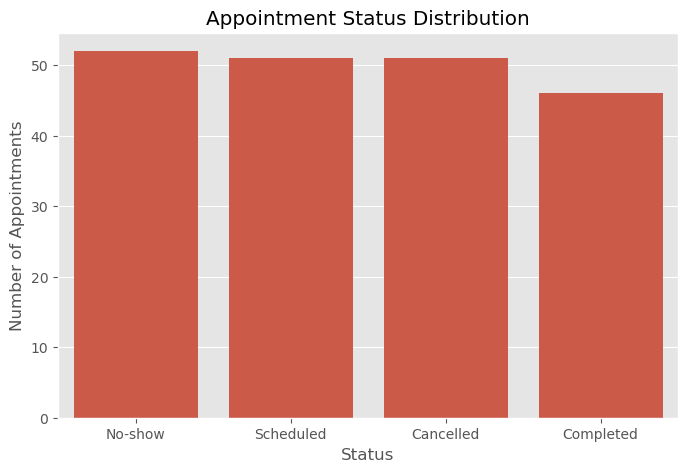

In [100]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=appointments,
    x='status',
    order=appointments['status'].value_counts().index
)

plt.title('Appointment Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Appointments')

plt.show()

No-show appointments were slightly higher than other appointment statuses.
This suggests that patient attendance could be improved to make hospital scheduling more efficient.

In [102]:
## Monthly Appointment Trend

In [104]:
appointments['Month'] = appointments['appointment_date'].dt.month

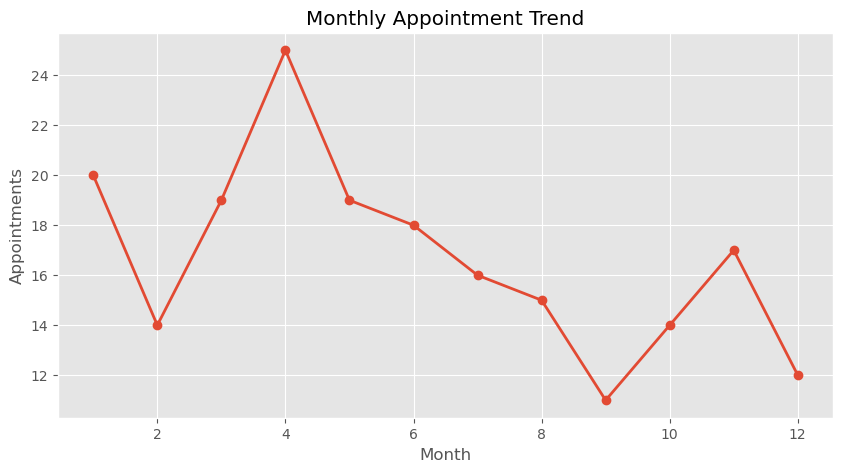

In [106]:
monthly = appointments.groupby('Month').size()

plt.figure(figsize=(10,5))

monthly.plot(
    marker='o',
    linewidth=2
)

plt.title('Monthly Appointment Trend')
plt.xlabel('Month')
plt.ylabel('Appointments')

plt.grid(True)

plt.show()

The number of appointments changed throughout the year. The highest number of appointments was recorded in April, while September had the lowest number of appointments.

In [108]:
## Visit Reason Analysis

In [110]:
appointments['reason_for_visit'].value_counts()

reason_for_visit
Checkup         45
Consultation    43
Therapy         42
Follow-up       41
Emergency       29
Name: count, dtype: int64

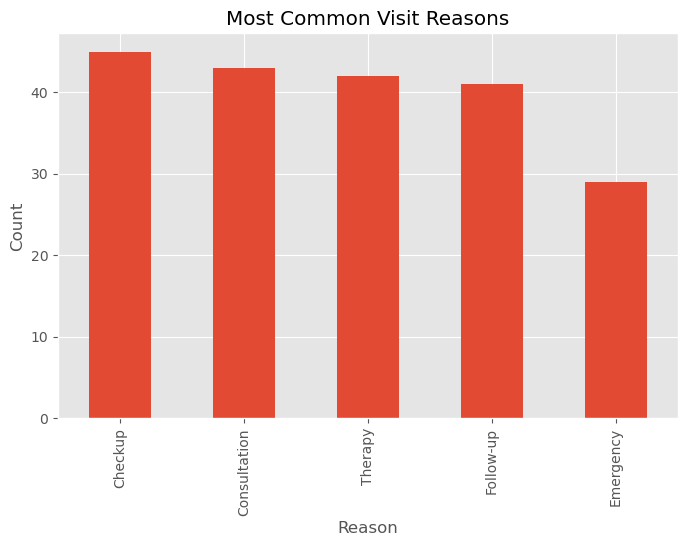

In [112]:
plt.figure(figsize=(8,5))

appointments['reason_for_visit'].value_counts().plot(
    kind='bar'
)

plt.title('Most Common Visit Reasons')
plt.xlabel('Reason')
plt.ylabel('Count')

plt.show()

Checkups were the most common reason for hospital visits, followed by consultations and therapy sessions. Emergency visits were less frequent compared to routine healthcare services.

In [116]:
## Treatment Revenue Analysis 

In [118]:
treatment_revenue = treatment_billing.groupby(
    'treatment_type'
)['amount'].sum().sort_values(
    ascending=False
)

treatment_revenue

treatment_type
Chemotherapy     128855.68
MRI              116098.16
X-Ray            110653.67
Physiotherapy     99418.10
ECG               96224.24
Name: amount, dtype: float64

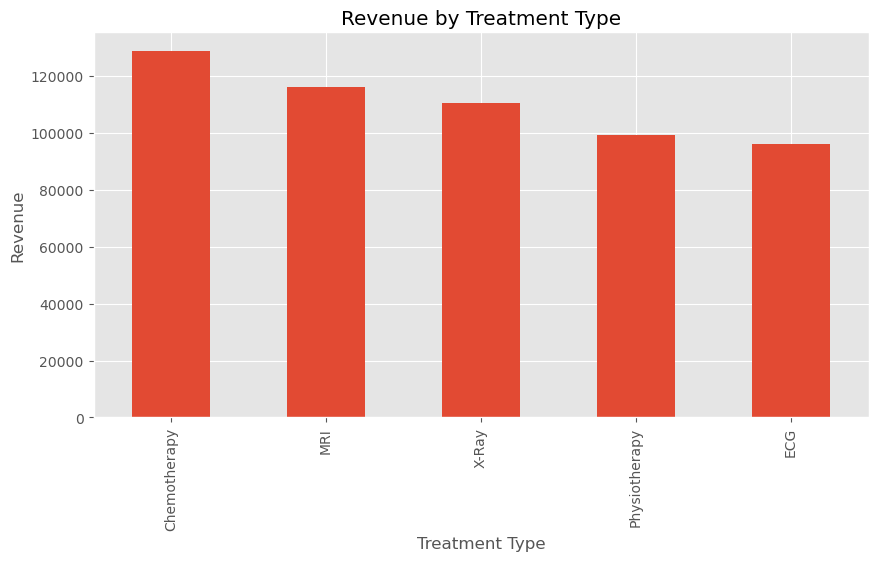

In [150]:
plt.figure(figsize=(10,5))

treatment_revenue.plot(
    kind='bar'
)

plt.title('Revenue by Treatment Type')
plt.xlabel('Treatment Type')
plt.ylabel('Revenue')

plt.show()

Chemotherapy generated the highest revenue among all treatment types. MRI and X-Ray treatments also contributed significantly to the hospital's revenue.

In [123]:
## Payment Method Analysis

In [125]:
billing['payment_method'].value_counts()

payment_method
Credit Card    75
Insurance      64
Cash           61
Name: count, dtype: int64

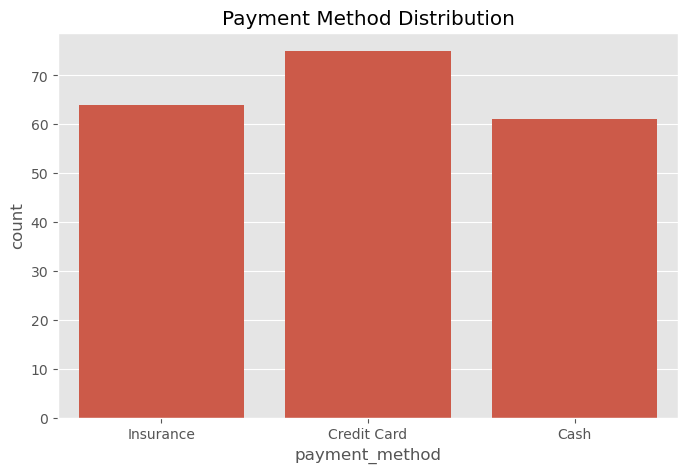

In [128]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=billing,
    x='payment_method'
)

plt.title('Payment Method Distribution')

plt.show()

Credit Card was the most commonly used payment method, followed by Insurance and Cash. This shows that many patients prefer digital payment options.

In [ ]:
## Payment Status Analysis

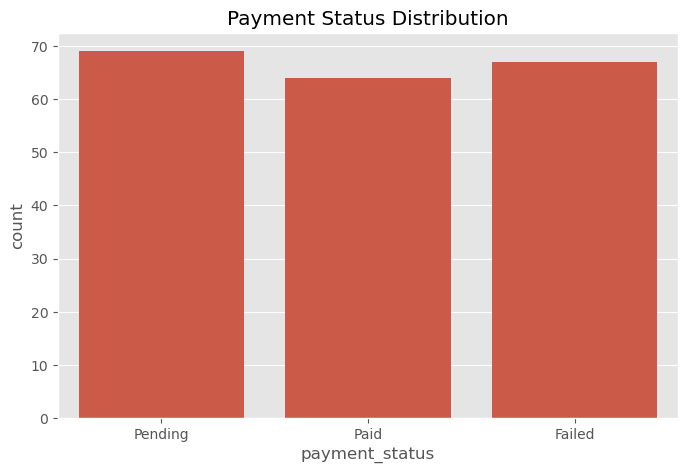

In [130]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=billing,
    x='payment_status'
)

plt.title('Payment Status Distribution')

plt.show()

Pending payments were slightly higher than paid payments. This indicates that the hospital may need better follow-up processes for outstanding bills.

In [132]:
## Doctor Performance Analysis

In [134]:
doctor_performance = doctor_appointments.groupby(
    ['first_name','last_name']
).size().sort_values(
    ascending=False
)

doctor_performance.head(10)

first_name  last_name
Sarah       Taylor       29
David       Taylor       25
Alex        Davis        24
Jane        Smith        22
            Davis        21
Linda       Wilson       19
Sarah       Smith        17
Linda       Brown        16
David       Jones        14
Robert      Davis        13
dtype: int64

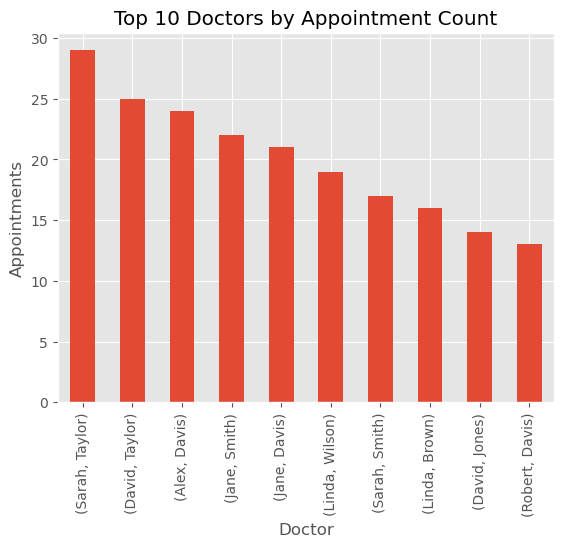

In [137]:
doctor_performance.head(10).plot(
    kind='bar'
)

plt.title('Top 10 Doctors by Appointment Count')
plt.xlabel('Doctor')
plt.ylabel('Appointments')

plt.show()

Dr. Sarah Taylor handled the highest number of appointments, followed by Dr. David Taylor and Dr. Alex Davis. Some doctors received more appointments than others, indicating higher patient demand.

In [ ]:
## Specialization Analysis 

In [139]:
specialization_count = doctor_appointments.groupby(
    'specialization'
).size().sort_values(
    ascending=False
)

specialization_count

specialization
Pediatrics     98
Dermatology    70
Oncology       32
dtype: int64

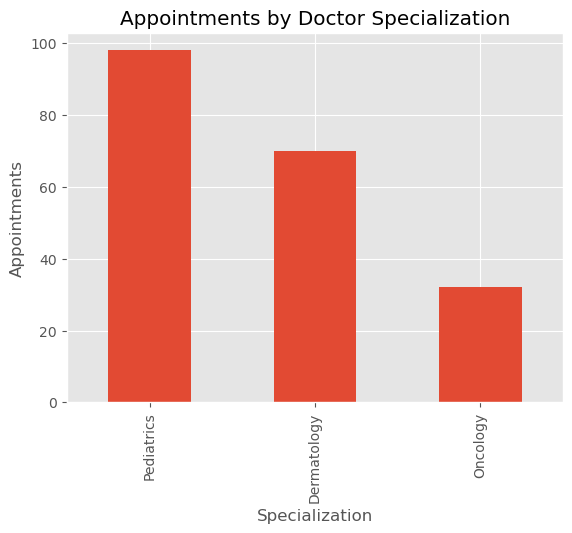

In [142]:
specialization_count.plot(
    kind='bar'
)

plt.title('Appointments by Doctor Specialization')
plt.xlabel('Specialization')
plt.ylabel('Appointments')

plt.show()

Pediatrics had the highest number of appointments, followed by Dermatology. Oncology had the lowest number of appointments among the three specializations.

# 8. Business Insights

1. No-show appointments were slightly higher than completed appointments, which may lead to inefficient use of hospital resources and scheduling slots.

2. Checkups were the most common reason for hospital visits, indicating that preventive and routine healthcare services are in high demand.

3. Chemotherapy generated the highest revenue among all treatment types, making it a major contributor to hospital income.

4. Credit Card was the most preferred payment method, showing that patients are comfortable using digital payment options.

5. A large number of payments were still pending, suggesting an opportunity to improve billing and payment collection processes.

6. Pediatric services received the highest number of appointments, indicating greater demand for child healthcare services.

7. Appointment volumes varied throughout the year, with the highest number of appointments recorded in April.

8. A small group of doctors handled a large number of appointments, which may indicate higher patient preference or specialization demand.

# 9. Conclusions

This project analyzed hospital management data using SQL and Python to understand patient visits, appointments, treatments, billing, and doctor performance.

The analysis showed that checkups were the most common reason for visits, Pediatrics had the highest number of appointments, and Chemotherapy generated the highest revenue. Credit Card was the most frequently used payment method, while a significant number of payments remained pending.

Overall, this analysis demonstrates how data can be used to identify trends, improve hospital operations, support decision-making, and enhance healthcare service management.